In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import os, shutil
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from torchvision import models
import tqdm

## Image Dir

In [ ]:
image_dir = "/home/tanmay/Work/IT549/IT549_Labs/Lab_3/DL_Assignment_3-20260313T103541Z-1-001/DL_Assignment_3/sampled_images"
csv_file = "/home/tanmay/Work/IT549/IT549_Labs/Lab_3/DL_Assignment_3-20260313T103541Z-1-001/DL_Assignment_3/data.csv"
output_dir = "/home/tanmay/Work/IT549/IT549_Labs/Lab_3/sorted_images"

os.makedirs(output_dir, exist_ok=True)

with open(csv_file, "r") as f:
    reader = pd.read_csv(f)

    for _, row in reader.iterrows():
        image_name = row.iloc[0]      # first column
        class_name = row.iloc[-1]     # last column

        src_path = os.path.join(image_dir, image_name)

        class_folder = os.path.join(output_dir, class_name)
        os.makedirs(class_folder, exist_ok=True)

        dst_path = os.path.join(class_folder, image_name)

        if os.path.exists(src_path):
            shutil.copy(src_path, dst_path)

count = 0

for class_name in os.listdir(output_dir):
    class_folder = os.path.join(output_dir, class_name)
    if os.path.isdir(class_folder):
        num_images = len(os.listdir(class_folder))
        print(f"{class_name}: {num_images} images")
        count += num_images

print(f"Total images: {count}")

a_Good: 1000 images
b_Moderate: 1000 images
c_Unhealthy_for_Sensitive_Groups: 1000 images
d_Unhealthy: 1000 images
e_Very_Unhealthy: 1000 images
f_Severe: 1000 images
Total images: 6000


## Train - val - test split

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=output_dir, transform=transform)

dataset_size = len(full_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 4200
Validation size: 900
Test size: 900


## Model

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, input_shape=(3, 224, 224), num_classes=6, dropout=0.3):
        super().__init__()
        in_channels = input_shape[0]

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),      
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
model = SimpleCNN(input_shape=(3, 224, 224), num_classes=6, dropout=0.3)

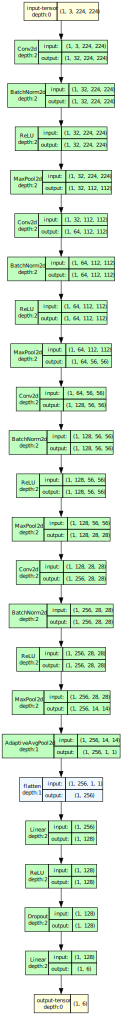

In [ ]:
from torchview import draw_graph

graph = draw_graph(
    model,
    input_size=(1,3,224,224)
)

graph.visual_graph

## Training Step

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (f"Using device: {device}")

model = model.to(device)
 

Using device: cuda


In [18]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    # training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for images, labels in train_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()         
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_bar.set_postfix(
            loss=f"{running_loss / (total / labels.size(0)):.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    train_acc = 100 * correct / total

    # validation 
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {running_loss / len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1/10 | Train Loss: 1.5170 | Train Acc: 41.71% | Val Acc: 52.78%


Epoch 2/10 | Train Loss: 1.2656 | Train Acc: 53.43% | Val Acc: 54.78%


Epoch 3/10 | Train Loss: 1.1244 | Train Acc: 57.95% | Val Acc: 58.78%


Epoch 4/10 | Train Loss: 1.0195 | Train Acc: 61.14% | Val Acc: 63.89%


Epoch 5/10 | Train Loss: 0.9527 | Train Acc: 63.48% | Val Acc: 67.44%


Epoch 6/10 | Train Loss: 0.8858 | Train Acc: 67.10% | Val Acc: 64.00%


Epoch 7/10 | Train Loss: 0.8437 | Train Acc: 68.17% | Val Acc: 66.67%


Epoch 8/10 | Train Loss: 0.8210 | Train Acc: 68.17% | Val Acc: 70.33%


Epoch 9/10 | Train Loss: 0.7763 | Train Acc: 69.62% | Val Acc: 70.11%


Epoch 10/10 | Train Loss: 0.7480 | Train Acc: 70.79% | Val Acc: 67.22%


In [19]:

model_path = "simple_cnn.pth"

if os.path.exists(model_path):
    state_dict = torch.load(model_path)
    model.load_state_dict(state_dict)
    print(f"Model loaded from {model_path}")
else:
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Model loaded from simple_cnn.pth


Test Accuracy: 76.22%


Text(0.5, 1.0, 'Confusion Matrix')

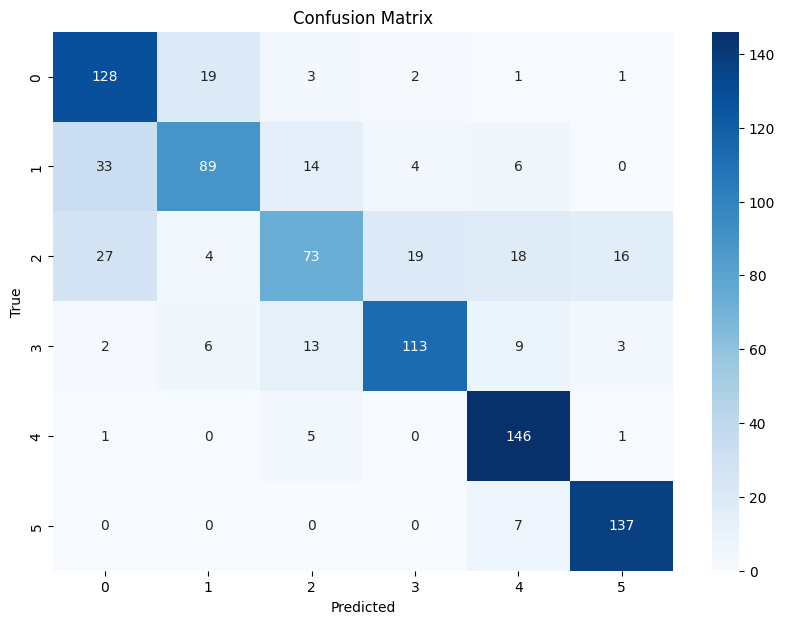

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()

test_correct = 0
all_labels = []
all_preds = []
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")



plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# RESNET

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

all_layers = list(model.named_children())
print("All layers:")
for i, (name, _) in enumerate(all_layers):
    print(f"  [{i}] {name}")

layers_to_freeze = [layer for _, layer in all_layers[:10]]
for layer in layers_to_freeze:
    for param in layer.parameters():
        param.requires_grad = False

in_features = model.fc.in_features  # 512 for ResNet18
model.fc = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 6)
)

model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/tanmay/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:23<00:00, 2.01MB/s]


All layers:
  [0] conv1
  [1] bn1
  [2] relu
  [3] maxpool
  [4] layer1
  [5] layer2
  [6] layer3
  [7] layer4
  [8] avgpool
  [9] fc
Trainable: 66,438 / 11,242,950  (0.6%)


In [ ]:
optimizer = torch.optim.Adam(lr=1e-4)

criterion = nn.CrossEntropyLoss()  

In [ ]:
num_epochs = 30
best_val_acc = 0.0
patience_counter = 0
patience = 7

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    train_bar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_bar.set_postfix(loss=f"{running_loss/len(train_loader):.4f}", acc=f"{100*correct/total:.2f}%")

    train_acc = 100 * correct / total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images), 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    # early stopping + best model checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "resnet_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping triggered after {epoch+1} epochs")
            break

print(f"\nBest Val Acc: {best_val_acc:.2f}%")
model.load_state_dict(torch.load("best_model.pth"))  

Epoch 1/30 | Train Acc: 32.40% | Val Acc: 54.67%
  ✓ Saved best model (val_acc: 54.67%)


Epoch 2/30 | Train Acc: 46.86% | Val Acc: 57.33%
  ✓ Saved best model (val_acc: 57.33%)


Epoch 3/30 | Train Acc: 53.07% | Val Acc: 61.67%
  ✓ Saved best model (val_acc: 61.67%)


Epoch 4/30 | Train Acc: 57.31% | Val Acc: 66.33%
  ✓ Saved best model (val_acc: 66.33%)


Epoch 5/30 | Train Acc: 58.98% | Val Acc: 67.56%
  ✓ Saved best model (val_acc: 67.56%)


...

Epoch 13/30 | Train Acc: 72.29% | Val Acc: 76.56%


Epoch 14/30 | Train Acc: 74.33% | Val Acc: 79.00%
  ✓ Saved best model (val_acc: 79.00%)


Epoch 15/30 | Train Acc: 75.76% | Val Acc: 78.67%


Epoch 16/30 | Train Acc: 75.21% | Val Acc: 80.22%
  ✓ Saved best model (val_acc: 80.22%)


Epoch 17/30:  29%|██▉       | 38/132 [00:04<00:11,  7.90it/s, acc=78.54%, loss=0.2690]

In [ ]:
test_correct = 0
test_total = 0
all_labels, all_preds = [], []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()